In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist_ubyte
from tqdm import tqdm

(60000, 784) (60000,)
(10000, 784) (10000,)


In [2]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [3]:
def relu(x):
    return np.maximum(0, x)

In [4]:
def relu_prime(x):
    return (x > 0).astype(np.float32)

In [5]:
def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

In [6]:
def cross_entropy_from_logits(logits, y):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
    log_probs = shifted - log_sum_exp
    return -np.mean(log_probs[np.arange(len(y)), y])

In [7]:
def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

In [8]:
def accuracy_from_logits(logits, y):
    pred = np.argmax(logits, axis=1)
    return np.mean(pred == y)

In [ ]:
class MLP:
    def __init__(self, H=2):
        self.H = H
        self.params = {}

        dims = [784] + [128] * (H + 1) + [10]

        for l in range(1, len(dims)):
            fan_in = dims[l - 1]
            fan_out = dims[l]
            self.params[f"W{l}"] = (
                np.random.randn(fan_in, fan_out).astype(np.float32) * np.sqrt(2.0 / fan_in)
            )
            self.params[f"b{l}"] = np.zeros((1, fan_out), dtype=np.float32)

        self.L = len(dims) - 1

    def forward(self, x):
        cache = {"A0": x}
        a = x

        for l in range(1, self.L):
            z = a @ self.params[f"W{l}"] + self.params[f"b{l}"]
            a = relu(z)
            cache[f"Z{l}"] = z
            cache[f"A{l}"] = a

        zL = a @ self.params[f"W{self.L}"] + self.params[f"b{self.L}"]
        cache[f"Z{self.L}"] = zL

        return zL, cache  # logits bruts + cache

    def backward(self, y, cache):
        grads = {}
        m = len(y)

        logits = cache[f"Z{self.L}"]
        probs = softmax(logits)
        Y = one_hot(y, num_classes=10)

        dZ = (probs - Y) / m

        A_prev = cache[f"A{self.L - 1}"]
        grads[f"W{self.L}"] = A_prev.T @ dZ
        grads[f"b{self.L}"] = np.sum(dZ, axis=0, keepdims=True)

        dA = dZ @ self.params[f"W{self.L}"].T

        for l in range(self.L - 1, 0, -1):
            dZ = dA * relu_prime(cache[f"Z{l}"])
            A_prev = cache[f"A{l - 1}"]

            grads[f"W{l}"] = A_prev.T @ dZ
            grads[f"b{l}"] = np.sum(dZ, axis=0, keepdims=True)

            if l > 1:
                dA = dZ @ self.params[f"W{l}"].T

        return grads

    def step(self, grads, lr=0.01):
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] -= lr * grads[f"W{l}"]
            self.params[f"b{l}"] -= lr * grads[f"b{l}"]

In [10]:
def train(model, x_train, y_train, x_test, y_test, epochs=10, batch_size=64, lr=0.01):
    n = len(x_train)

    for epoch in range(epochs):
        for i in tqdm(range(0, n, batch_size)):
            x_batch = x_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            logits, cache = model.forward(x_batch)
            loss = cross_entropy_from_logits(logits, y_batch)

            grads = model.backward(y_batch, cache)
            model.step(grads, lr=lr)

        test_logits, _ = model.forward(x_test)
        test_loss = cross_entropy_from_logits(test_logits, y_test)
        accuracy = accuracy_from_logits(test_logits, y_test)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.4f}")

In [11]:
model = MLP(H=2)
train(model, x_train, y_train, x_test, y_test, epochs=10, batch_size=64, lr=0.01)

100%|██████████| 938/938 [00:02<00:00, 315.02it/s]


Epoch 1/10, Loss: 0.1864, Test Loss: 0.3300, Accuracy: 0.9039


100%|██████████| 938/938 [00:03<00:00, 304.20it/s]


Epoch 2/10, Loss: 0.1098, Test Loss: 0.2555, Accuracy: 0.9255


100%|██████████| 938/938 [00:03<00:00, 302.58it/s]


...

Epoch 8/10, Loss: 0.0302, Test Loss: 0.1396, Accuracy: 0.9569


100%|██████████| 938/938 [00:05<00:00, 178.64it/s]


Epoch 9/10, Loss: 0.0279, Test Loss: 0.1323, Accuracy: 0.9596


100%|██████████| 938/938 [00:03<00:00, 275.08it/s]


Epoch 10/10, Loss: 0.0259, Test Loss: 0.1261, Accuracy: 0.9613


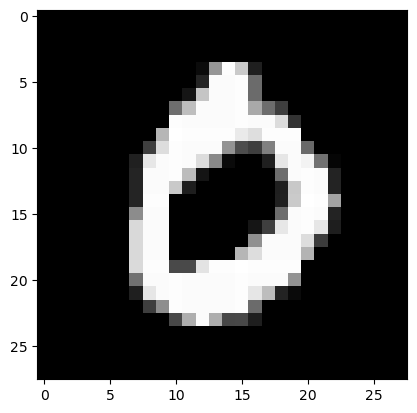

In [12]:
plt.imshow(x_test[3].reshape(28, 28), cmap="gray")
plt.show()

In [13]:
def predicted_details(res):
    for i, prob in enumerate(res):
        print(f"{i}: {prob*100:.2f}%")

In [18]:
logits, _ = model.forward(x_test[3:4])
probs = softmax(logits)[0]
predicted_details(probs)

0: 99.98%
1: 0.00%
2: 0.01%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.01%
